# Differential abundance analysis with MILO

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_milo
# python -m ipykernel install --user --name scrna_cartography_milo --display-name "milo"

# https://github.com/scverse/pertpy-tutorials/blob/86069936d9d811e23558ddefb462ed78ba3eaaa9/milo.ipynb

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc

# milo
import pertpy as pt
milo = pt.tl.Milo()
import mudata as md

# Parallel processing
from joblib import Parallel, delayed, parallel_backend

# dataframes
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt 

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import diff_genes as dg
import misc as mi

/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Create directories
mi.create_directories(dir_path = str(here('data/milo/files')))
mi.create_directories(dir_path = str(here('data/milo/plots')))
mi.create_directories(dir_path = str(here('data/milo/objects')))

/work/islet_cartography_scrna/data/milo/files Directory already exists!
/work/islet_cartography_scrna/data/milo/plots Directory already exists!
/work/islet_cartography_scrna/data/milo/objects Directory already exists!


In [3]:
# Paths
base_dir = str(here('data/milo/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
objects_dir = os.path.join(base_dir, 'objects') 
anndata_dir = str(here('data/anndata/'))

In [4]:
disease_order = ["nd", "pre", "t2d"]

## Load

In [5]:
adata = ad.read_h5ad(os.path.join(anndata_dir, "AH_combined.h5ad"))

## Prepare for Milo analysis

In [6]:
## Initialize object for Milo analysis
mdata = milo.load(adata)

## Build KNN graph

Here the value of k indicates the smallest possible size of neighbourhood in which we will quantify differential abundance (i.e. with k=50 the smallest neighbourhood will have 50 cells). Depending on the number of samples, you might want to use a high value of k for neighbourhood analysis, to have sufficient power to estimate abundance fold-changes. Since here we have data from > 100 patients, we set k=150 to have on average more than one cell per donor in each neighbourhood.

In [7]:
print(f'Number of samples: {mdata['rna'].obs['ic_id_platform_adjusted_sample'].value_counts().count()}')

Number of samples: 333


In [8]:
# default
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
sc.pp.neighbors(mdata["rna"], use_rep="X_latent_1", transformer=AnnoyTransformer(666))

## Assign cells to neighborhoods

Laymen terms: We have defined using the nighbors function which cells are closest to each other, not we need to create groups of these nearby cells.
So we have a graph that shows which cells that are most similar to each other, and instead of using every cells, we use the 10 % of cells to act as a starting point for defining the neighborhoods. (so we start by looking at these cells neighbors first). Then the neighborshoods are cleaned for those that are overlapping and avoid hvaing too many neighbors that are similar. Then it finds the center of each neighborhood and then reassigns that neighborshood to the single cell closest to the center. If multiple neighborhoods end up centered on the same cell, they are merged. This way we can hopefully avoid oversamling neighborhoods

In [9]:
# default
milo.make_nhoods(mdata["rna"], prop = 0.05, seed = 1000)

See cells that are sampled as index cells of representative neighborhoods, along with their distance of the index to the kth nearest neighbor.

In [14]:
mdata["rna"][mdata["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
ic_15_1_1_AAACCCAGTTGGACCC,1,1.128246
ic_15_1_1_AAAGAACTCACCTACC,1,1.055247
ic_15_1_1_AACACACGTTACACAC,1,0.878108
ic_15_1_1_AATGGAAGTGCACGCT,1,0.769526
ic_15_1_1_ACAAGCTAGGCCACTC,1,1.074433
...,...,...
ic_7_2_4_TTAGGGTAGGCATGGT,1,0.869168
ic_7_2_4_TTCTGTACACGGTCTG,1,1.384178
ic_7_2_4_TTTACCACAATGTTGC,1,1.234712
ic_7_3_6_CGGGTCATCAACCGAT,1,1.296705


Plot the distributions of neighborhood sizes, we wantto check that the minimal value of k makes sense, and that the distrubtion of sizes are not too wide

Each row in the nhoods graph is a neighborhood, and a cell can be assigned to multiple neighborhoods

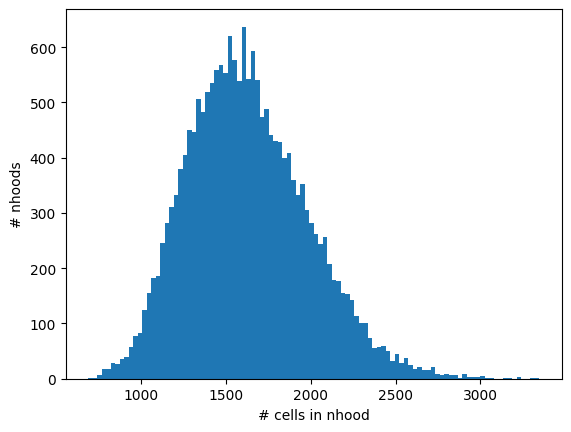

In [13]:
# Get sum per row
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods");

### Count cells in neighbourhoods

Count how many cells for each sample there are in each neighborhood, so we can use it later to account for variations in cell numbers between replicates of the same condition when we test for differential abundance

In [15]:
mdata = milo.count_nhoods(mdata, sample_col="ic_id_platform_adjusted_sample")
# Stored here: mdata['milo'].X

In [16]:
count_mat = mdata['milo'].X.T.toarray()
frac_zeros = np.mean(count_mat == 0)
frac_zeros

np.float64(0.5619846948184822)

#### Plot number of (cells?) from each donor in each neighborhood

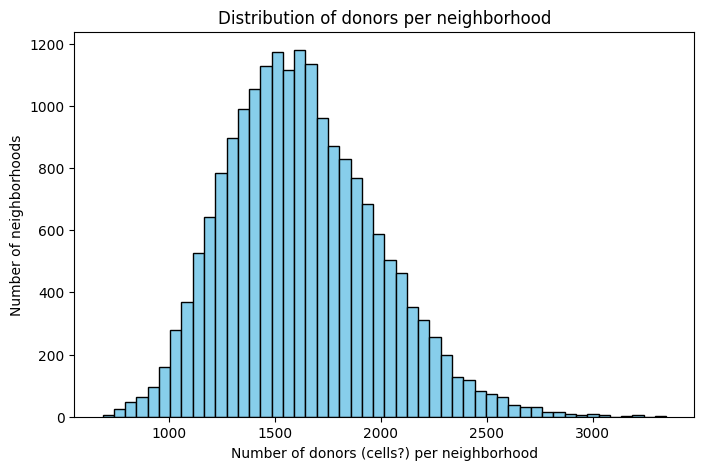

In [17]:
X = mdata['milo'].X  # CSR sparse matrix

# 1. Count donors per neighborhood (sum over rows)
donors_per_neighborhood = X.sum(axis=0)  

# Convert to 1D array
donors_per_neighborhood = np.array(donors_per_neighborhood).flatten()

# 2. Plot histogram
plt.figure(figsize=(8,5))
plt.hist(donors_per_neighborhood, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Number of donors (cells?) per neighborhood")
plt.ylabel("Number of neighborhoods")
plt.title("Distribution of donors per neighborhood")
plt.show()

### Man burde måske også teste for om cellerne er fundet i donorerne i forvejen fx i pre vs nd, så kommer der færrer af mange celler, men er det bare fordi der ikke er nogle donorer

## Testing differential abundance across diabetes status

In [18]:
import re
import numpy as np
import pandas as pd
from anndata import AnnData
from mudata import MuData
import logging
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

logger = logging.getLogger(__name__)

def milo_da_nhoods(
    mdata: MuData,
    design: str,
    model_contrasts: str | None = None,
    subset_samples: list[str] | None = None,
    add_intercept: bool = True,
    feature_key: str | None = "rna"
) -> AnnData:
    # Extract milo slot
    try:
        sample_adata = mdata["milo"]
    except KeyError:
        logger.error(
            "milo_mdata should be a MuData object with a 'milo' slot - please run milopy.count_nhoods() first"
        )
        raise

    # Extract main feature slot
    adata = mdata[feature_key]

    # Parse covariates from design formula
    covariates = [x.strip() for x in set(re.split(r"\+|\*", design.lstrip("~ ")))]

    # Get sample metadata
    sample_col = sample_adata.uns["sample_col"]
    try:
        sample_obs = adata.obs[covariates + [sample_col]].drop_duplicates()
    except KeyError as e:
        missing_cov = [x for x in covariates if x not in adata.obs.columns]
        logger.warning(f"Covariates {missing_cov} are not columns in adata.obs")
        raise e

    sample_obs.index = sample_obs[sample_col].astype(str)

    # Ensure one-to-one mapping between sample_adata and covariates
    try:
        assert sample_obs.loc[sample_adata.obs_names].shape[0] == len(sample_adata.obs_names)
    except AssertionError:
        logger.warning(
            f"Values in mdata[{feature_key}].obs[{covariates}] cannot be unambiguously assigned to each sample"
        )
        raise

    sample_adata.obs = sample_obs.loc[sample_adata.obs_names]

    # Prepare design dataframe
    design_df = sample_adata.obs[covariates]

    # Get count matrix
    count_mat = sample_adata.X.T.toarray()
    lib_size = count_mat.sum(axis=0)

    # Filter zero-count samples
    keep_smp = lib_size > 0

    # Subset samples if requested
    if subset_samples is not None:
        keep_smp = keep_smp & sample_adata.obs_names.isin(subset_samples)
        design_df = design_df[keep_smp]
        for col in design_df.columns:
            if pd.api.types.is_categorical_dtype(design_df[col]):
                design_df[col] = design_df[col].cat.remove_unused_categories()

    # Filter zero-count neighborhoods
    keep_nhoods = count_mat[:, keep_smp].sum(axis=1) > 0
    counts_filtered = count_mat[np.ix_(keep_nhoods, keep_smp)]
    design_df_filtered = design_df.iloc[keep_smp].copy()

    # Ensure categorical covariates are categories
    for col in design_df_filtered.select_dtypes(exclude=["number"]).columns:
        design_df_filtered[col] = design_df_filtered[col].astype("category")

    design_clean = design if design.startswith("~") else f"~{design}"

    # Build DESeq dataset
    dds = DeseqDataSet(
        counts=pd.DataFrame(counts_filtered.T, index=design_df_filtered.index),
        metadata=design_df_filtered,
        design=design_clean,
        size_factors_fit_type="poscounts",
        refit_cooks=True,
    )
    dds.deseq2()

    # Run contrast or default comparison
    factor_name = design_clean.replace("~", "").split("+")[-1].strip()
    if model_contrasts is not None:
        if "-" not in model_contrasts:
            raise ValueError("Contrast must be in 'GroupA-GroupB' format")
        if "(" in model_contrasts or "+" in model_contrasts.split("-")[1]:
            raise ValueError(
                f"Complex contrasts like '{model_contrasts}' are not supported by pydeseq2"
            )
        group1, group2 = [x.replace(factor_name, "").strip() for x in model_contrasts.split("-")]
        stat_res = DeseqStats(dds, contrast=[factor_name, group1, group2])
    else:
        categories = design_df_filtered[factor_name].cat.categories
        stat_res = DeseqStats(dds, contrast=[factor_name, categories[-1], categories[0]])

    stat_res.summary()
    res = stat_res.results_df.rename(
        columns={"baseMean": "logCPM", "log2FoldChange": "logFC", "pvalue": "PValue", "padj": "FDR"}
    )[['logCPM', 'logFC', 'PValue', 'FDR']]

    # Align results with var
    res.index = sample_adata.var_names[keep_nhoods]
    sample_adata.var = pd.concat([sample_adata.var.drop(res.columns, axis=1, errors='ignore'), res], axis=1)

    # Apply spatial FDR
    milo._graph_spatial_fdr(sample_adata)

    return sample_adata

In [19]:
mdata["rna"].obs["sample_cell_count"] = (
    mdata["rna"].obs.groupby("ic_id_platform_adjusted_sample")["ic_id_platform_adjusted_sample"]
    .transform("count")
)

In [42]:
from mudata import MuData

# 1. Run your custom DE analysis
res_adata = milo_da_nhoods(
    mdata,
    design="~sample_cell_count+disease_harmonized",
    model_contrasts="disease_harmonizedpre-disease_harmonizednd"
)

# 2. Add the results back into your MuData object, overwrite the excisting modality
mdata.mod["milo"] = res_adata


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.25 seconds.

Fitting dispersions...
... done in 2.54 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 2.45 seconds.

Fitting LFCs...
... done in 3.29 seconds.

Calculating cook's distance...
... done in 0.95 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: disease_harmonized pre vs nd
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      1.516837        0.683301  0.528486  1.292940  0.196032  0.432944
1      1.667181       -1.484393  0.665936 -2.229034  0.025812  0.147306
2      1.885805       -0.405930  0.376760 -1.077422  0.281292  0.520222
3      1.890581        0.753879  0.474594  1.588470  0.112180  0.323146
4      1.382267        0.793102  0.553786  1.432145  0.152102  0.378550
...         ...             ...       ...       ...       ...       ...
19079  1.056139        0.419937  0.412925  1.016981  0.309162  0.546035
19080  2.200282       -3.217958  0.768274 -4.188558  0.000028  0.003280
19081  2.423169       -3.575434  0.997860 -3.583103  0.000340  0.013443
19082  1.866538       -2.091461  0.747630 -2.797455  0.005151  0.061860
19083  2.011655       -0.346389  0.683001 -0.507158  0.612044  0.778693

[19084 rows x 6 columns]


... done in 2.56 seconds.



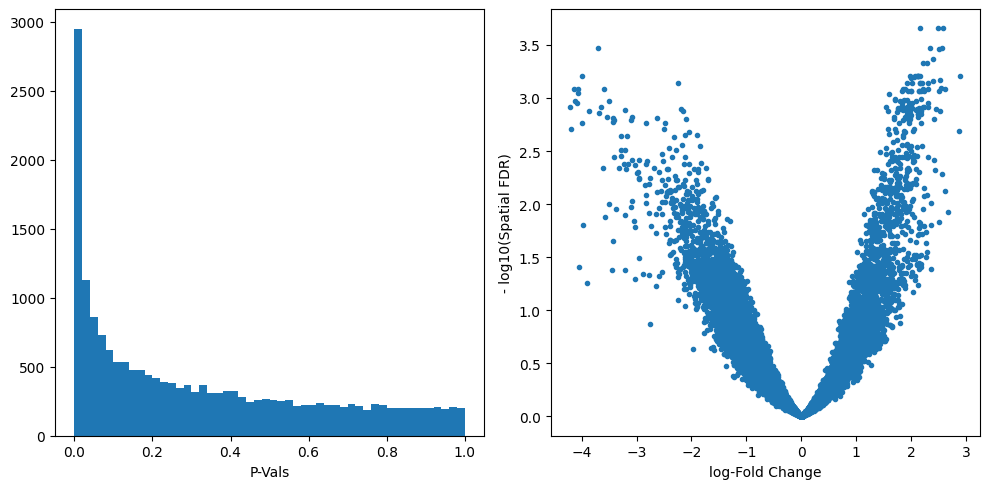

In [43]:
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata["milo"].var.logFC, -np.log10(mdata["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

Visualize on embedding

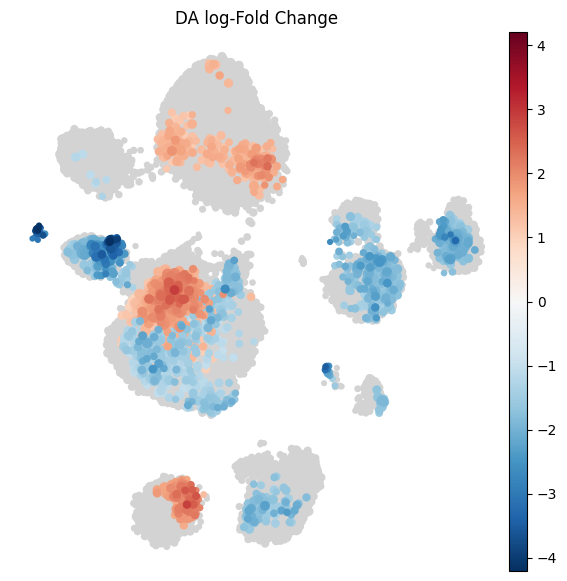

In [44]:
milo.build_nhood_graph(mdata)
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata,
    alpha=0.1,  # SpatialFDR level (10%)
    min_size=0.1,  # Size of smallest dot
)

By cell type

In [23]:
milo.annotate_nhoods(mdata, anno_col="manual_annotation")

Text(0.5, 0, 'celltype fraction')

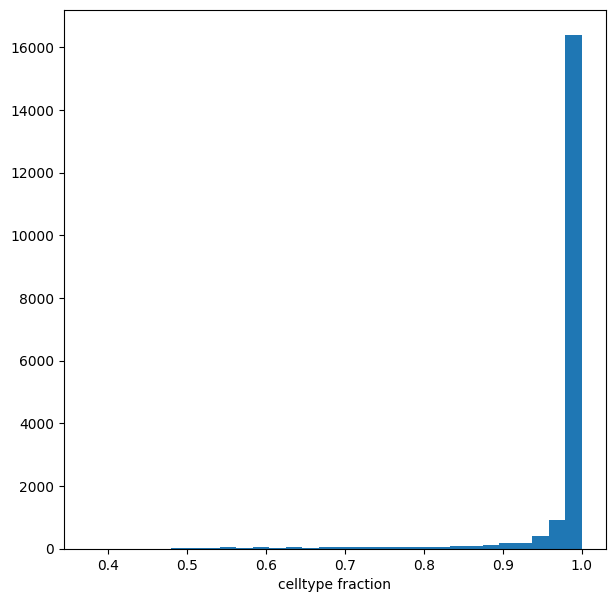

In [24]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [25]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

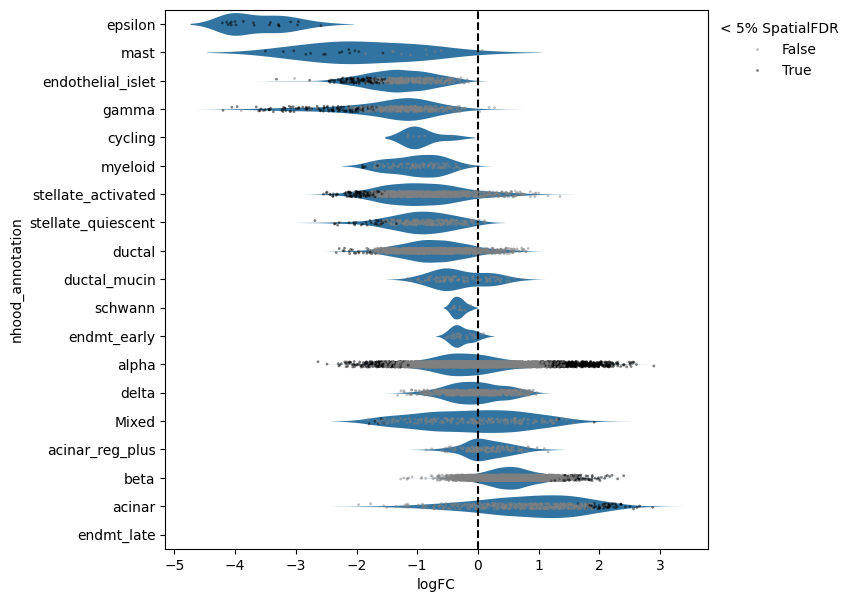

In [50]:
milo.plot_da_beeswarm(mdata, alpha=0.05)

In [27]:
mdata["milo"].obs["disease_harmonized"] = (
    mdata["milo"].obs["disease_harmonized"].astype("category").cat.reorder_categories(disease_order)
)

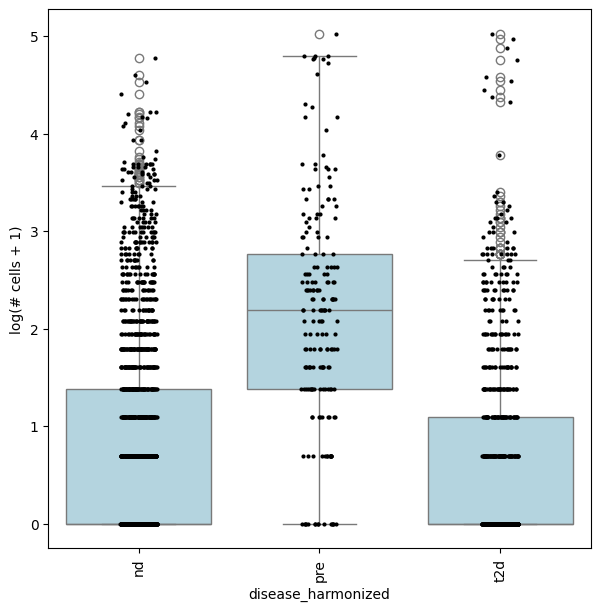

In [46]:
pl_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < 0.01) & (mdata["milo"].var["logFC"] > 2) & (mdata["milo"].var["nhood_annotation"] == "beta")
]
milo.plot_nhood_counts_by_cond(mdata, test_var="disease_harmonized", subset_nhoods=pl_nhoods, log_counts= True)

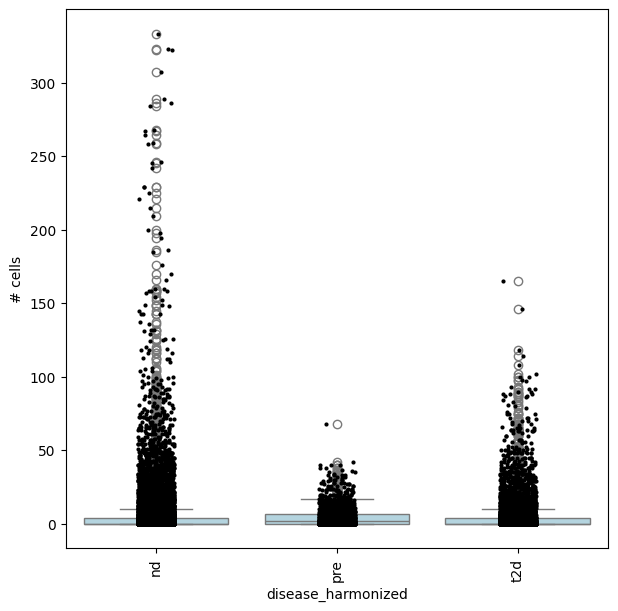

In [48]:
pl_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < 0.1) &
    (mdata["milo"].var["logFC"] < -1) &
    (mdata["milo"].var["nhood_annotation"] == "ductal")
]

milo.plot_nhood_counts_by_cond(mdata, test_var="disease_harmonized", subset_nhoods=pl_nhoods)

### Save MuData object

In [41]:
mdata.write(os.path.join(objects_dir,"mdata_666.h5mu"))

In [ ]:
mdata = md.read(os.path.join(objects_dir,"mdata.h5mu"))